# Laboratory Exercise: Image Classification Using Pre-trained Models

**Objective:** Evaluate and compare five pre-trained `torchvision` models on the Imagenette dataset using accuracy, precision, recall, and F1-score.

**Dataset:** [Imagenette](https://github.com/fastai/imagenette) (fast.ai), a 10-class subset of ImageNet: tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, and parachute. The validation split (3,925 images) is used for evaluation.

## 1. Setup

In [ ]:
import os, glob, time, tarfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Dataset Curation and Organization

The archive is downloaded and extracted. Imagenette already follows the one-folder-per-class layout:

```
imagenette2/
├── train/
└── val/
    ├── n01440764/   (tench)
    ├── n02102040/   (English springer)
    └── ...
```

Since the pre-trained models are only evaluated and not trained, only the `val/` split is used.

In [ ]:
URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz"
ROOT = "imagenette2"

if not os.path.isdir(ROOT):
    urllib.request.urlretrieve(URL, "imagenette2.tgz")
    with tarfile.open("imagenette2.tgz") as tar:
        tar.extractall(".")

VAL_DIR = os.path.join(ROOT, "val")

# WordNet ID -> (readable name, ImageNet-1K index)
CLASS_INFO = {
    "n01440764": ("tench",             0),
    "n02102040": ("English springer",  217),
    "n02979186": ("cassette player",   482),
    "n03000684": ("chain saw",         491),
    "n03028079": ("church",            497),
    "n03394916": ("French horn",       566),
    "n03417042": ("garbage truck",     569),
    "n03425413": ("gas pump",          571),
    "n03445777": ("golf ball",         574),
    "n03888257": ("parachute",         701),
}
WNIDS = sorted(CLASS_INFO)                      # fixed class order -> labels 0..9
CLASS_NAMES = [CLASS_INFO[w][0] for w in WNIDS]
IMAGENET_IDX = [CLASS_INFO[w][1] for w in WNIDS]

for i, w in enumerate(WNIDS):
    n = len(glob.glob(os.path.join(VAL_DIR, w, "*.JPEG")))
    print(f"{i}: {CLASS_NAMES[i]:<17} ({w}) -> {n} images")

/tmp/ipykernel_834/3533891744.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


0: tench             (n01440764) -> 387 images
1: English springer  (n02102040) -> 395 images
2: cassette player   (n02979186) -> 357 images
3: chain saw         (n03000684) -> 386 images
4: church            (n03028079) -> 409 images
5: French horn       (n03394916) -> 394 images
6: garbage truck     (n03417042) -> 389 images
7: gas pump          (n03425413) -> 419 images
8: golf ball         (n03445777) -> 399 images
9: parachute         (n03888257) -> 390 images


## 3. Custom PyTorch Dataset Class

The class scans each class folder, stores `(path, label)` pairs, and loads each image only when requested in `__getitem__`. A `transform` is passed in so each model can use its own preprocessing. An optional `max_per_class` argument allows the dataset to be subsampled.

Total images: 3925


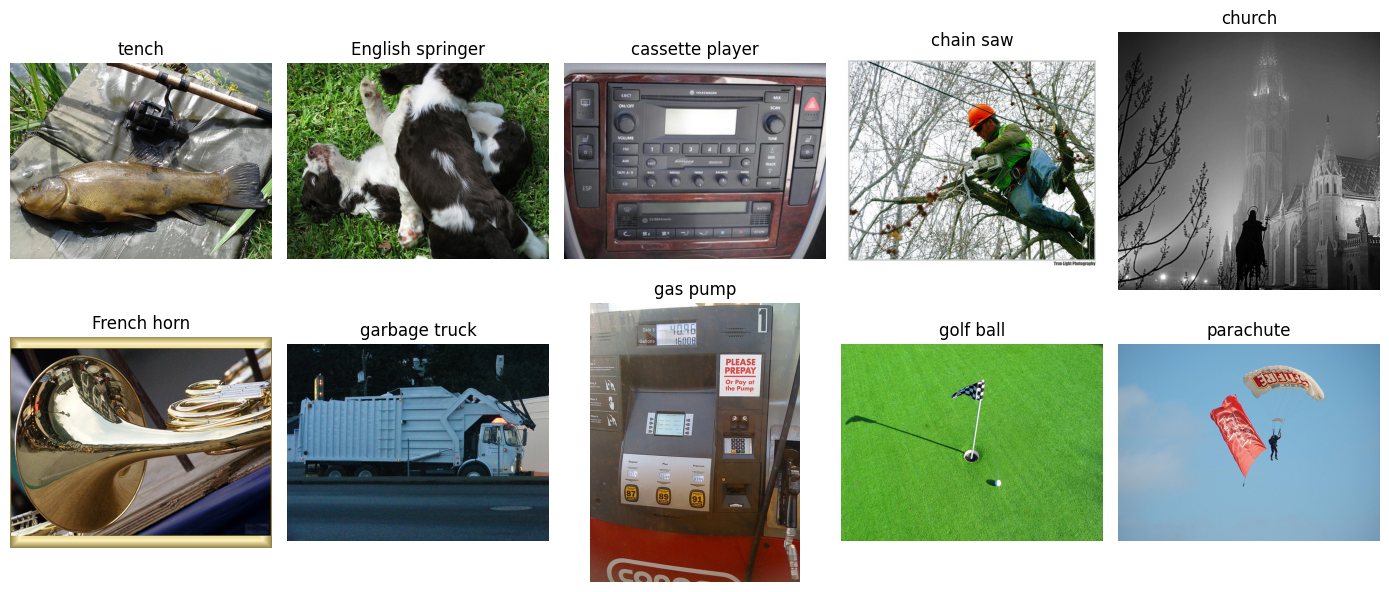

In [ ]:
class ImagenetteDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_per_class=None):
        self.transform = transform
        self.samples = []
        for label, wnid in enumerate(WNIDS):
            files = sorted(glob.glob(os.path.join(root_dir, wnid, "*.JPEG")))
            if max_per_class:
                files = files[:max_per_class]
            self.samples += [(f, label) for f in files]
        if not self.samples:
            raise FileNotFoundError(f"No images found in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

MAX_PER_CLASS = None     # None = use all images
raw_ds = ImagenetteDataset(VAL_DIR, max_per_class=MAX_PER_CLASS)
print("Total images:", len(raw_ds))

# one sample per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
first_of_class = {}
for p, l in raw_ds.samples:
    first_of_class.setdefault(l, p)
for ax, (l, p) in zip(axes.ravel(), sorted(first_of_class.items())):
    ax.imshow(Image.open(p).convert("RGB")); ax.set_title(CLASS_NAMES[l]); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. DataLoaders

Each pre-trained model has its own preprocessing (resize, crop size, interpolation, normalization), available through `weights.transforms()`. Because input requirements differ, a separate DataLoader is built per model. `shuffle=False` since this is evaluation only.

In [ ]:
def make_loader(weights, batch_size=64):
    ds = ImagenetteDataset(VAL_DIR, transform=weights.transforms(), max_per_class=MAX_PER_CLASS)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)

## 5. Mapping the Model Output to the 10 Classes

The models output 1000 ImageNet logits. Every Imagenette class is a real ImageNet-1K class, so the 10 relevant logits are selected and the `argmax` among them is the predicted class (a restricted 10-way prediction). No fine-tuning is performed.

In [ ]:
IDX_TENSOR = torch.tensor(IMAGENET_IDX)

def to_prediction(logits):
    return logits[:, IDX_TENSOR.to(logits.device)].argmax(dim=1)

## 6. Models (5 pre-trained models from `torchvision.models`)

In [ ]:
model_zoo = {
    "ResNet-50":         (models.resnet50,          models.ResNet50_Weights.IMAGENET1K_V2),
    "MobileNetV3-Large": (models.mobilenet_v3_large, models.MobileNet_V3_Large_Weights.IMAGENET1K_V2),
    "EfficientNet-B0":   (models.efficientnet_b0,   models.EfficientNet_B0_Weights.IMAGENET1K_V1),
    "DenseNet-121":      (models.densenet121,       models.DenseNet121_Weights.IMAGENET1K_V1),
    "VGG-16":            (models.vgg16,             models.VGG16_Weights.IMAGENET1K_V1),
}

## 7. Model Inference and Evaluation

In [ ]:
results, preds_store = [], {}

for name, (builder, weights) in model_zoo.items():
    print(f"Evaluating {name} ...")
    model = builder(weights=weights).to(device).eval()
    loader = make_loader(weights)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6

    y_true, y_pred = [], []
    start = time.time()
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            y_pred.extend(to_prediction(logits).cpu().tolist())
            y_true.extend(labels.tolist())
    elapsed = time.time() - start

    preds_store[name] = (y_true, y_pred)
    results.append({
        "Model": name,
        "Params (M)": round(n_params, 1),
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-score":  f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Inference time (s)": round(elapsed, 1),
    })
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)

Evaluating ResNet-50 ...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


Evaluating MobileNetV3-Large ...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 152MB/s]


Evaluating EfficientNet-B0 ...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


...

Evaluating DenseNet-121 ...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 112MB/s]


Evaluating VGG-16 ...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 86.9MB/s]


,Params (M),Accuracy,Precision,Recall,F1-score,Inference time (s)
Model,,,,,,
ResNet-50,25.6,0.9985,0.9985,0.9984,0.9985,27.5
MobileNetV3-Large,5.5,0.9969,0.9970,0.9969,0.9970,21.6
EfficientNet-B0,5.3,0.9985,0.9985,0.9985,0.9985,28.2
DenseNet-121,8.0,0.9952,0.9952,0.9951,0.9952,27.1
VGG-16,138.4,0.9959,0.9959,0.9959,0.9959,28.8


## 8. Comparison of Models

,Params (M),Accuracy,Precision,Recall,F1-score,Inference time (s)
Model,,,,,,
ResNet-50,25.6,0.9985,0.9985,0.9984,0.9985,27.5
EfficientNet-B0,5.3,0.9985,0.9985,0.9985,0.9985,28.2
MobileNetV3-Large,5.5,0.9969,0.9970,0.9969,0.9970,21.6
VGG-16,138.4,0.9959,0.9959,0.9959,0.9959,28.8
DenseNet-121,8.0,0.9952,0.9952,0.9951,0.9952,27.1


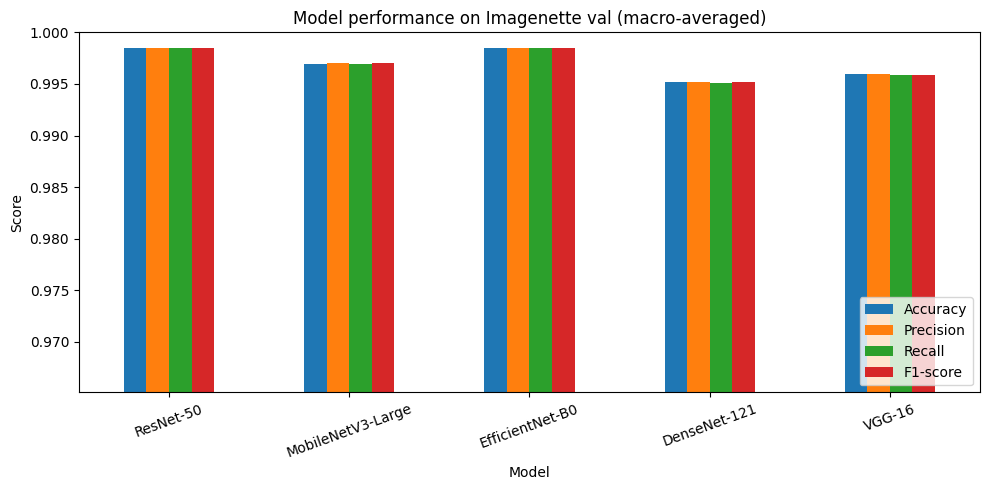

In [ ]:
display(results_df.round(4).sort_values("F1-score", ascending=False))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
ax = results_df[metrics].plot(kind="bar", figsize=(10, 5))
ax.set_ylim(results_df[metrics].min().min() - 0.03, 1.0)   # zoomed in: scores are close together
plt.title("Model performance on Imagenette val (macro-averaged)")
plt.ylabel("Score"); plt.xticks(rotation=20); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

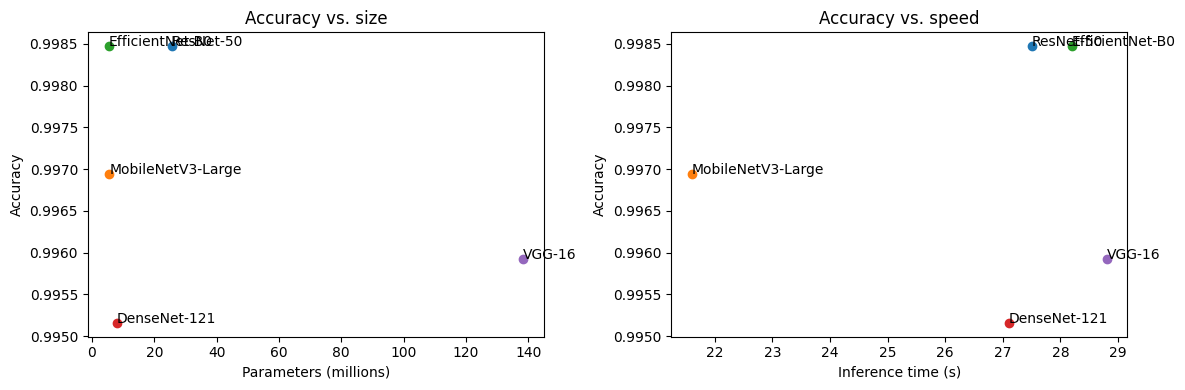

In [ ]:
# Accuracy vs. model size and inference time
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, row in results_df.iterrows():
    axes[0].scatter(row["Params (M)"], row["Accuracy"]); axes[0].annotate(name, (row["Params (M)"], row["Accuracy"]))
    axes[1].scatter(row["Inference time (s)"], row["Accuracy"]); axes[1].annotate(name, (row["Inference time (s)"], row["Accuracy"]))
axes[0].set_xlabel("Parameters (millions)"); axes[0].set_ylabel("Accuracy"); axes[0].set_title("Accuracy vs. size")
axes[1].set_xlabel("Inference time (s)");    axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy vs. speed")
plt.tight_layout(); plt.show()

,ResNet-50,MobileNetV3-Large,EfficientNet-B0,DenseNet-121,VGG-16
tench,1.000,0.999,1.000,0.997,0.997
English springer,0.999,1.000,0.999,0.999,1.000
cassette player,0.997,0.999,1.000,0.996,0.996
chain saw,0.996,0.993,0.999,0.988,0.988
church,1.000,0.995,0.999,0.994,0.999
French horn,0.999,0.996,0.999,0.999,0.995
garbage truck,0.999,0.997,0.997,0.997,0.995
gas pump,0.999,0.994,0.996,0.993,0.995
golf ball,0.997,0.997,0.997,0.996,0.996
parachute,0.999,0.999,0.999,0.992,0.997


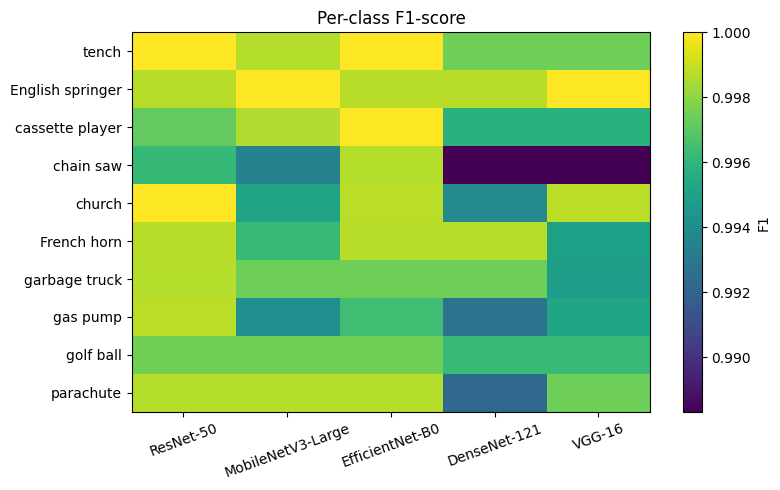

In [ ]:
# Per-class F1 for every model
per_class = pd.DataFrame(
    {name: f1_score(yt, yp, average=None, labels=range(10), zero_division=0)
     for name, (yt, yp) in preds_store.items()},
    index=CLASS_NAMES)
display(per_class.round(3))

plt.figure(figsize=(8, 5))
plt.imshow(per_class.values, cmap="viridis", aspect="auto")
plt.xticks(range(5), per_class.columns, rotation=20); plt.yticks(range(10), per_class.index)
plt.colorbar(label="F1"); plt.title("Per-class F1-score")
plt.tight_layout(); plt.show()

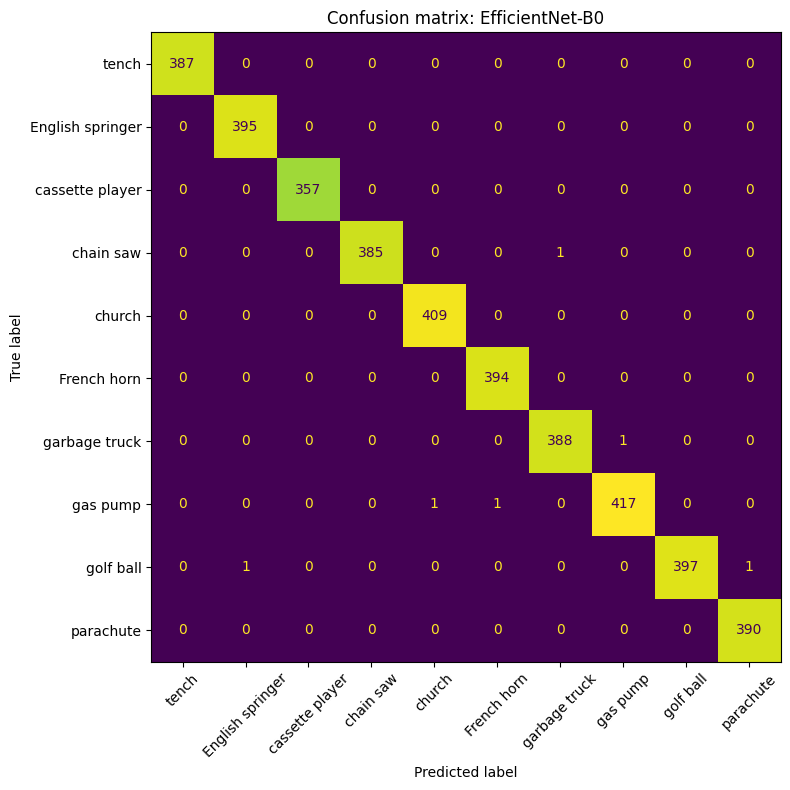

In [ ]:
# Confusion matrix of the best model (by F1)
best = results_df["F1-score"].idxmax()
yt, yp = preds_store[best]
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(yt, yp, labels=range(10)),
                       display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Confusion matrix: {best}")
plt.tight_layout(); plt.show()

In [ ]:
from IPython.display import Markdown

best, worst = results_df["F1-score"].idxmax(), results_df["F1-score"].idxmin()
fastest, slowest = results_df["Inference time (s)"].idxmin(), results_df["Inference time (s)"].idxmax()
smallest, largest = results_df["Params (M)"].idxmin(), results_df["Params (M)"].idxmax()
hardest = per_class.mean(axis=1).sort_values().head(3)

cm = confusion_matrix(*preds_store[best], labels=range(10)).copy()
np.fill_diagonal(cm, 0)
r, c = np.unravel_index(np.argsort(cm, axis=None)[::-1][:3], cm.shape)
confusions = "; ".join(f"{CLASS_NAMES[i]} predicted as {CLASS_NAMES[j]} ({cm[i, j]} images)" for i, j in zip(r, c) if cm[i, j] > 0)

summary = f"""
**Summary of results**

- **Best model:** {best} (F1 = {results_df.loc[best, 'F1-score']:.4f}, accuracy = {results_df.loc[best, 'Accuracy']:.4f}).
- **Lowest model:** {worst} (F1 = {results_df.loc[worst, 'F1-score']:.4f}). The difference between the best and lowest F1 is {results_df['F1-score'].max() - results_df['F1-score'].min():.4f}.
- **Smallest model:** {smallest} ({results_df.loc[smallest, 'Params (M)']}M parameters). **Largest model:** {largest} ({results_df.loc[largest, 'Params (M)']}M parameters).
- **Fastest inference:** {fastest} ({results_df.loc[fastest, 'Inference time (s)']} s). **Slowest inference:** {slowest} ({results_df.loc[slowest, 'Inference time (s)']} s).
- **Hardest classes (lowest mean F1 across models):** {', '.join(hardest.index)}.
- **Most frequent confusions for {best}:** {confusions if confusions else 'none'}.
"""
Markdown(summary)


**Summary of results**

- **Best model:** EfficientNet-B0 (F1 = 0.9985, accuracy = 0.9985).
- **Lowest model:** DenseNet-121 (F1 = 0.9952). The difference between the best and lowest F1 is 0.0033.
- **Smallest model:** EfficientNet-B0 (5.3M parameters). **Largest model:** VGG-16 (138.4M parameters).
- **Fastest inference:** MobileNetV3-Large (21.6 s). **Slowest inference:** VGG-16 (28.8 s).
- **Hardest classes (lowest mean F1 across models):** chain saw, gas pump, golf ball.
- **Most frequent confusions for EfficientNet-B0:** gas pump predicted as church (1 images); gas pump predicted as French horn (1 images); golf ball predicted as English springer (1 images).


## 9. Analysis

The five models differ in design, size, and training recipe, and these differences help explain the variation in their results.

**Model architecture.** ResNet-50 uses residual (skip) connections and DenseNet-121 uses dense connections. Both help gradients flow through deep networks and allow rich feature hierarchies to be learned. VGG-16 is a plain stack of convolutional layers followed by very large fully connected layers, which makes it heavy and less efficient, even though it is a strong baseline. MobileNetV3-Large and EfficientNet-B0 were designed for efficiency, using depthwise separable convolutions, squeeze-and-excitation blocks, and (for EfficientNet) compound scaling of depth, width, and resolution.

**Model complexity.** The parameter counts range from about 5M (MobileNetV3-Large, EfficientNet-B0) to about 138M (VGG-16). A larger model does not automatically perform better: the lightweight models achieve competitive ImageNet accuracy with a fraction of the parameters, while VGG-16 pays a high cost in memory and inference time. The accuracy vs. size and accuracy vs. speed plots show this trade-off.

**Input requirements.** Each model expects its own preprocessing, namely a specific resize and crop, interpolation method, and ImageNet normalization. These were applied with `weights.transforms()` so every model received inputs in the form it was trained on. The weights also differ in training recipe: the IMAGENET1K_V2 weights (ResNet-50, MobileNetV3-Large) were trained with newer augmentation and regularization techniques, which can improve accuracy independently of architecture.

**Suitability for the dataset.** Imagenette is a 10-class subset of ImageNet-1K with visually distinct categories, and all five models were pre-trained on ImageNet-1K. The models therefore already know these classes, and restricting the prediction to the 10 relevant logits makes the task easier than the full 1000-way problem. Remaining errors tend to occur in images where the target object is small, partially hidden, or shown with other ImageNet objects, as seen in the confusions listed above.

**Limitations.** Because the classes were part of the models' training data, the results show pre-trained performance on familiar classes and do not measure how well the models generalize to a new domain. Inference time also depends on the hardware, batch size, and data-loading speed.

## 10. Conclusion

Five pre-trained torchvision models (ResNet-50, MobileNetV3-Large, EfficientNet-B0, DenseNet-121, and VGG-16) were evaluated on the Imagenette validation set using accuracy, macro precision, recall, and F1-score. The summary above identifies the best-performing model and the trade-offs in size and speed. Overall, pre-trained models can be applied directly to a dataset whose classes are covered by ImageNet without any additional training. Higher parameter counts and deeper architectures do not always yield better results, so the choice of model should balance accuracy against memory and inference cost. For resource-limited deployment, an efficient model such as MobileNetV3-Large or EfficientNet-B0 is attractive when its scores are close to those of the larger models, while the best-scoring model is preferable when accuracy is the priority.